# NYC Housing Predictions - Time Series with Prophet

Import Libraries and Mount Google Drive

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
from prophet import Prophet

In [2]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
/gdrive


# Import Dataset

In [3]:
df = pd.read_csv('/gdrive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Modern Time Series Forecasting Techniques /CAPSTONE PROJECT_ Prophet/DHS_weekly.csv')
df.head()

,Date,Total Individuals in Shelter,Easter,Thanksgiving,Christmas,Temperature
0,1/5/2014,354354,0,0,0,0.848000
1,1/12/2014,358103,0,0,0,3.257143
2,1/19/2014,359491,0,0,0,5.632857
3,1/26/2014,362880,0,0,0,-1.850000
4,2/2/2014,364125,0,0,0,1.177143


Create a copy of the dataframe for various EDA purposes

In [4]:
df_copy = pd.read_csv('/gdrive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Modern Time Series Forecasting Techniques /CAPSTONE PROJECT_ Prophet/DHS_weekly.csv',index_col='Date',parse_dates=True)
df_copy.rename_axis(None, inplace=True)
df_copy.head()

,Total Individuals in Shelter,Easter,Thanksgiving,Christmas,Temperature
2014-01-05,354354,0,0,0,0.848000
2014-01-12,358103,0,0,0,3.257143
2014-01-19,359491,0,0,0,5.632857
2014-01-26,362880,0,0,0,-1.850000
2014-02-02,364125,0,0,0,1.177143


In [5]:
df['y'] = df['Total Individuals in Shelter']
df['ds'] = df['Date']
df['ds'] = pd.to_datetime(df['ds'],format='%m/%d/%Y')
df['temp'] = df['Temperature']
df.drop(['Total Individuals in Shelter','Date','Temperature'], axis=1, inplace=True)
df.head()

,Easter,Thanksgiving,Christmas,y,ds,temp
0,0,0,0,354354,2014-01-05,0.848000
1,0,0,0,358103,2014-01-12,3.257143
2,0,0,0,359491,2014-01-19,5.632857
3,0,0,0,362880,2014-01-26,-1.850000
4,0,0,0,364125,2014-02-02,1.177143


In [6]:
df_copy['y'] = df_copy['Total Individuals in Shelter']
df_copy.drop(['Total Individuals in Shelter'], axis=1, inplace=True)
df_copy.head()

,Easter,Thanksgiving,Christmas,Temperature,y
2014-01-05,0,0,0,0.848000,354354
2014-01-12,0,0,0,3.257143,358103
2014-01-19,0,0,0,5.632857,359491
2014-01-26,0,0,0,-1.850000,362880
2014-02-02,0,0,0,1.177143,364125


In [7]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 366 entries, 2014-01-05 to 2021-01-03
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Easter        366 non-null    int64  
 1   Thanksgiving  366 non-null    int64  
 2   Christmas     366 non-null    int64  
 3   Temperature   366 non-null    float64
 4   y             366 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 17.2 KB


In [8]:
df_copy.head()

,Easter,Thanksgiving,Christmas,Temperature,y
2014-01-05,0,0,0,0.848000,354354
2014-01-12,0,0,0,3.257143,358103
2014-01-19,0,0,0,5.632857,359491
2014-01-26,0,0,0,-1.850000,362880
2014-02-02,0,0,0,1.177143,364125


In [9]:
df_copy.tail()

,Easter,Thanksgiving,Christmas,Temperature,y
2020-12-06,0,0,0,10.072857,375444
2020-12-13,0,0,0,8.208571,375820
2020-12-20,0,0,0,3.535714,375615
2020-12-27,0,0,1,7.510000,374203
2021-01-03,0,0,0,6.625000,212514


Remove last observation from `df` and `df_copy` since it appears that it may be erroneous or incomplete.

In [10]:
df = df[:-1]
df_copy = df_copy[:-1]

# Useful Functions

In [11]:
# Function to assess model and visualize output

def model_assessment(train, test, predictions, chart_title):

  # Set the size of the plot to 10 inches by 4 inches
  plt.figure(figsize = (10,4))

  # Plot the train, test, and forecast data
  plt.plot(train, label = 'Train')
  plt.plot(test, label = 'Test')
  plt.plot(predictions, label = "Forecast")

  # add title and legend to the plot
  plt.title(f"Train, Test and Predictions with {chart_title}")
  plt.legend()
  plt.show()

  # Calculating the MAE, RMSE, and MAPE
  mae = mean_absolute_error(test, predictions)
  rmse = root_mean_squared_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)

  # Print the calculated error metrics
  print(f"The MAE is {mae:.2f}")
  print(f"The RMSE is {rmse:.2f}")
  print(f"The MAPE is {100 * mape:.2f} %")

  return

# Function to plot the future

def plot_future(y, forecast, title):

  # Set the size of the plot to 10 inches by 4 inches
  plt.figure(figsize = (10,4))

  # Plot the train and forecast data
  plt.plot(y, label = 'Train')
  plt.plot(forecast, label = "Forecast")

  # add title and legend to the plot
  plt.title(f"Train and Forecast with {title}")
  plt.legend()
  plt.show()

  return

Plot the target variable `y`

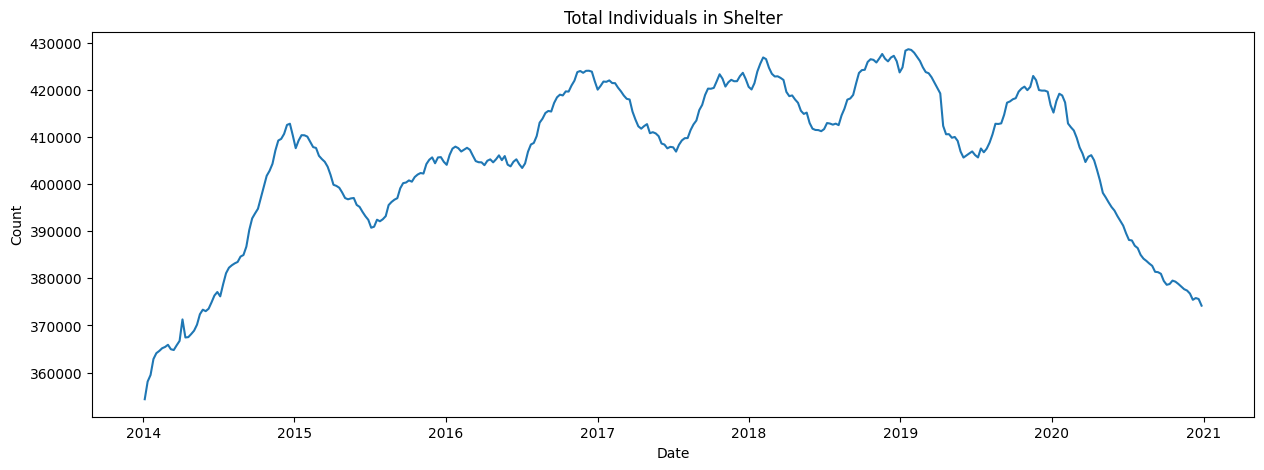

In [12]:
plt.figure(figsize = (15,5))
plt.plot(df_copy['y'])
plt.title('Total Individuals in Shelter')
plt.xlabel('Date')
plt.ylabel('Count')
plt.show()


In [13]:
df.index.freq = 'W'
df_copy = df_copy.asfreq('W')

# Month and Quarter Plots

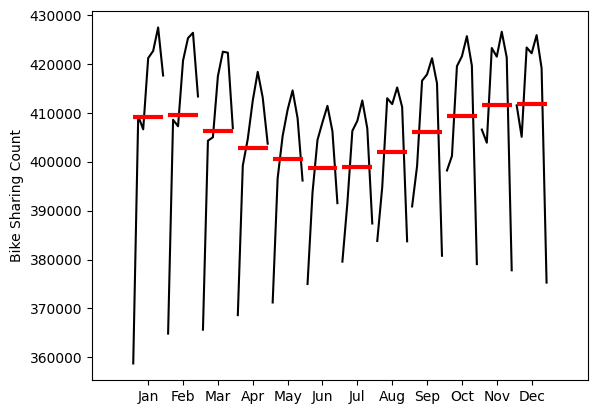

In [14]:
month_plot(df_copy['y'].resample('ME').mean())
plt.ylabel('Bike Sharing Count')
plt.show()

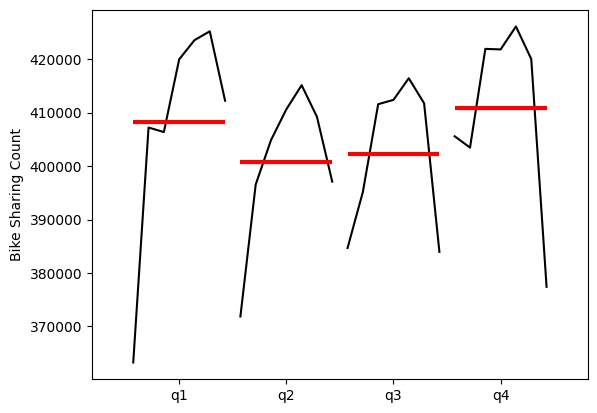

In [15]:
# Plot the quarter_plot
quarter_plot(df_copy['y'].resample('QE').mean())
plt.ylabel('Bike Sharing Count')
plt.show()


# Seasonal Decomposition

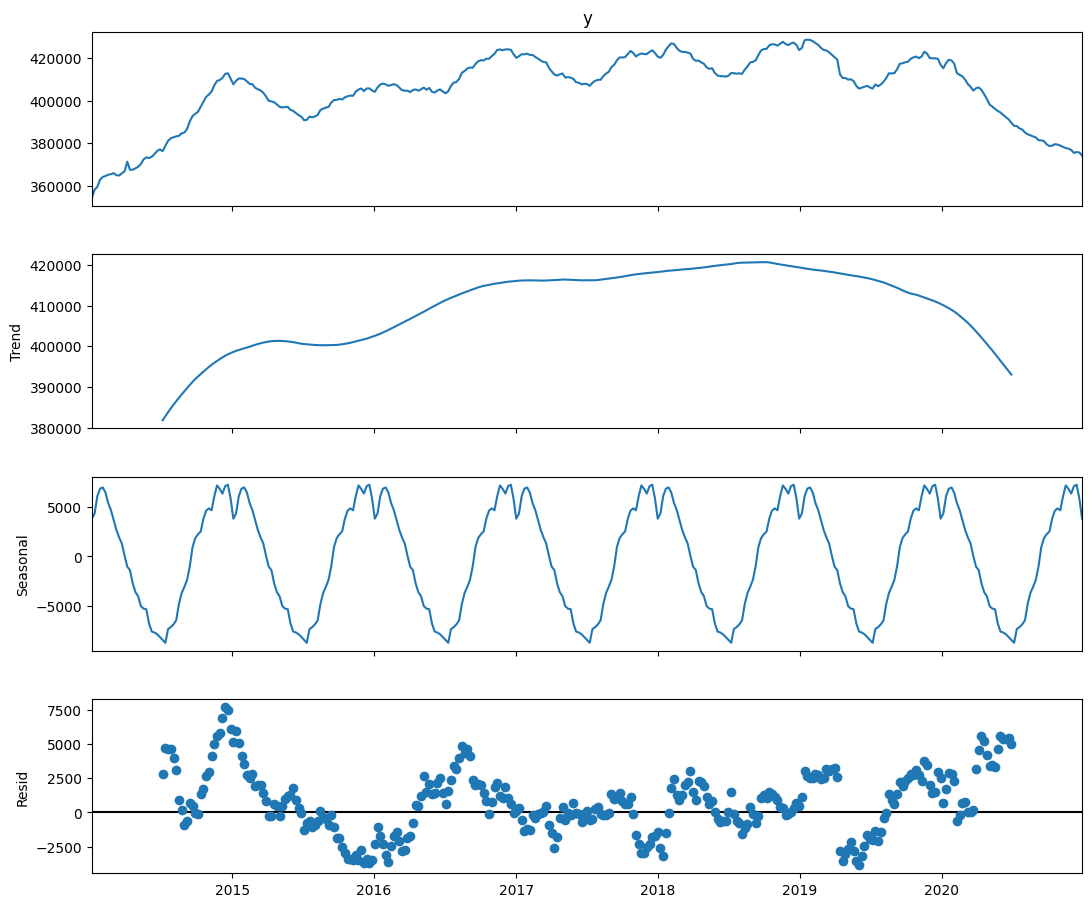

In [16]:
# Seasonal decomposition for df_copy['y']
decomposition = seasonal_decompose(df_copy['y'],
                                  model = 'additive',
                                  period = 52)
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()


# ACF & PACF

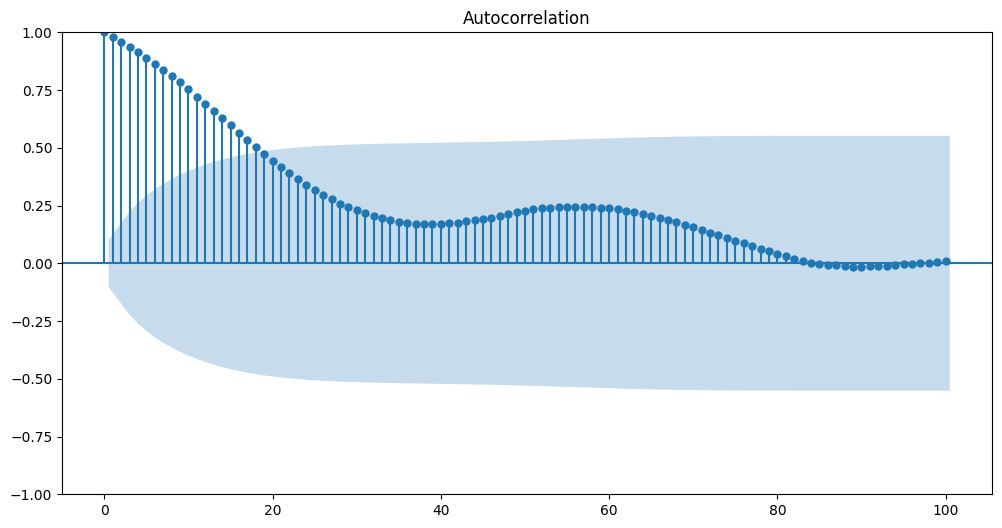

In [17]:
# Plot the ACF
fig, ax = plt.subplots(figsize = (12, 6))
plot_acf(df_copy['y'], lags = 100, ax = ax)
plt.show()


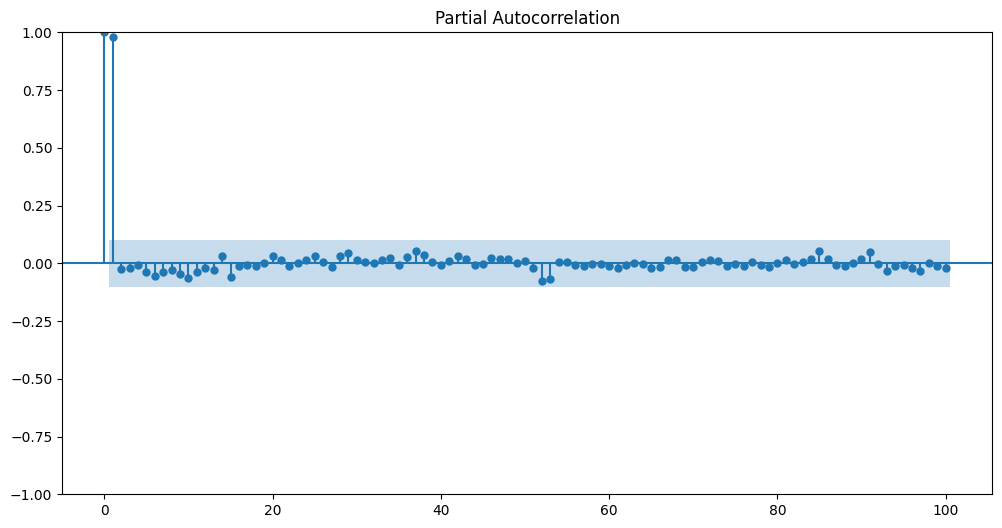

In [18]:
# PACF
fig, ax = plt.subplots(figsize = (12, 6))
plot_pacf(df_copy['y'], lags = 100, ax = ax)
plt.show()


# Stationarity

In [19]:
def adf_test(series, title=None):

  # Run the ADF test
  result = adfuller(series.dropna(), autolag='AIC')

  # Extract and print results
  print('ADF Statistic:', result[0])
  print('p-value:', result[1])
  print('Critical Values:')
  for key, value in result[4].items():
      print(f'   {key}: {value}')

  # Interpretation
  if result[1] < 0.05:
      print("Result: The series is likely stationary (reject H0).")
  else:
      print("Result: The series is likely non-stationary (fail to reject H0).")

In [20]:
adf_test(df_copy['y'])

ADF Statistic: -2.4677623835955727
p-value: 0.12351638350531091
Critical Values:
   1%: -3.448853029339765
   5%: -2.869693115704379
   10%: -2.571113512498422
Result: The series is likely non-stationary (fail to reject H0).


Let's compute the difference of `df_copy.y`

In [21]:
df_copy['y_diff'] = df_copy['y'].diff().dropna()
df_copy.head()


,Easter,Thanksgiving,Christmas,Temperature,y,y_diff
2014-01-05,0,0,0,0.848000,354354,NaN
2014-01-12,0,0,0,3.257143,358103,3749.0
2014-01-19,0,0,0,5.632857,359491,1388.0
2014-01-26,0,0,0,-1.850000,362880,3389.0
2014-02-02,0,0,0,1.177143,364125,1245.0


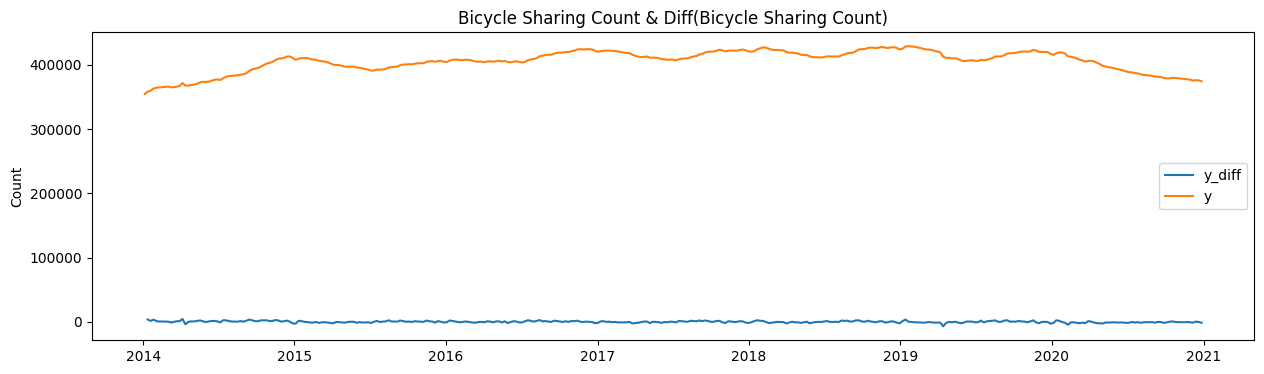

In [22]:
plt.figure(figsize = (15,4))
plt.plot(df_copy['y_diff'],label='y_diff')
plt.plot(df_copy['y'],label='y')
plt.legend()
plt.title("Bicycle Sharing Count & Diff(Bicycle Sharing Count)")
plt.ylabel("Count")
plt.show()

In [23]:
adf_test(df_copy['y_diff'])

ADF Statistic: -3.3863781884430155
p-value: 0.011432096564160102
Critical Values:
   1%: -3.4489583388155194
   5%: -2.869739378430086
   10%: -2.5711381780459
Result: The series is likely stationary (reject H0).


# Holidays in the dataframe

In [24]:
df['holiday'] = df['Christmas'] | df['Thanksgiving'] |  df['Easter']
df = df.drop(['Christmas', 'Thanksgiving', 'Easter'], axis=1)
df.head()

,y,ds,temp,holiday
0,354354,2014-01-05,0.848000,0
1,358103,2014-01-12,3.257143,0
2,359491,2014-01-19,5.632857,0
3,362880,2014-01-26,-1.850000,0
4,364125,2014-02-02,1.177143,0


In [25]:
df['holiday'].value_counts()

,count
holiday,
0,344
1,21


# Feature Engineering

Let's look at lags in the `Temperature` feature:

In [26]:
for lag in [1,2,3,4]:
  df[f'temp_lag_{lag}'] = df['temp'].shift(lag)
df.head()

,y,ds,temp,holiday,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4
0,354354,2014-01-05,0.848000,0,NaN,NaN,NaN,NaN
1,358103,2014-01-12,3.257143,0,0.848000,NaN,NaN,NaN
2,359491,2014-01-19,5.632857,0,3.257143,0.848000,NaN,NaN
3,362880,2014-01-26,-1.850000,0,5.632857,3.257143,0.848000,NaN
4,364125,2014-02-02,1.177143,0,-1.850000,5.632857,3.257143,0.848


Check correlations

In [27]:
# Create correlation matrix between the lagged values and y

columns = ['y'] + [col for col in df.columns if col.startswith('temp_lag_')]
corr_matrix = df[columns].corr()
corr_matrix

,y,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4
y,1.000000,-0.142916,-0.124860,-0.103336,-0.078502
temp_lag_1,-0.142916,1.000000,0.952593,0.923856,0.890964
temp_lag_2,-0.124860,0.952593,1.000000,0.952859,0.924467
temp_lag_3,-0.103336,0.923856,0.952859,1.000000,0.952866
temp_lag_4,-0.078502,0.890964,0.924467,0.952866,1.000000


Upon inspection of the correlation matrix, we see that the first three lags have a correlation with $y \approx -0.12$. So we will keep them in the dataset.

In [28]:
df.drop(['temp_lag_4'], axis=1, inplace=True)
df.head()

,y,ds,temp,holiday,temp_lag_1,temp_lag_2,temp_lag_3
0,354354,2014-01-05,0.848000,0,NaN,NaN,NaN
1,358103,2014-01-12,3.257143,0,0.848000,NaN,NaN
2,359491,2014-01-19,5.632857,0,3.257143,0.848000,NaN
3,362880,2014-01-26,-1.850000,0,5.632857,3.257143,0.848000
4,364125,2014-02-02,1.177143,0,-1.850000,5.632857,3.257143


# Prophet Model

Drop any rows in the dataframe that contain null values as the Prophet model cannot handle them.

In [29]:
df.dropna(inplace=True)

In [30]:
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='multiplicative',
    seasonality_prior_scale=10,
    holidays_prior_scale=10,
    changepoint_prior_scale=0.05
    )

model_prophet.add_regressor('temp')
model_prophet.add_regressor('holiday')
model_prophet.add_regressor('temp_lag_1')
model_prophet.add_regressor('temp_lag_2')
model_prophet.add_regressor('temp_lag_3')

model_prophet.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpmro45p6f/n0t99tly.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpmro45p6f/kt_tukib.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=5784', 'data', 'file=/tmp/tmpmro45p6f/n0t99tly.json', 'init=/tmp/tmpmro45p6f/kt_tukib.json', 'output', 'file=/tmp/tmpmro45p6f/prophet_model0r1qgrwd/prophet_model-20250731120247.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:02:47 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:02:49 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [31]:
# Get Regressor Coefficients

from prophet.utilities import regressor_coefficients
coef_df = regressor_coefficients(model_prophet)

Interpreting the Coefficients

In [32]:
def interpret_multiplicative_coeffs(df):
    interpretations = []

    for _, row in df.iterrows():
        reg = row['regressor']
        coef = row['coef']
        center = row['center']

        # Direction of effect
        direction = "increases" if coef > 0 else "decreases" if coef < 0 else "has no effect on"

        # Strength descriptor
        magnitude = abs(coef)
        if magnitude > 0.7:
            strength = "strongly"
        elif magnitude > 0.3:
            strength = "moderately"
        elif magnitude > 0:
            strength = "weakly"
        else:
            strength = "negligibly"

        # Special handling for binary or categorical features
        if reg.startswith('weathersit_'):
            context = f"When weather situation is category {reg[-1]}, demand {direction} {strength}."
        elif reg == 'workingday':
            context = f"On a working day, demand {direction} {strength}."
        else:
            context = (f"A unit increase in '{reg}' (from centered value {center:.2f}) "
                       f"{direction} demand {strength} in a multiplicative way.")

        interpretations.append(context)

    return interpretations


In [33]:
interpret_multiplicative_coeffs(coef_df)

["A unit increase in 'temp' (from centered value 14.96) decreases demand weakly in a multiplicative way.",
 "A unit increase in 'holiday' (from centered value 0.00) decreases demand weakly in a multiplicative way.",
 "A unit increase in 'temp_lag_1' (from centered value 14.96) decreases demand weakly in a multiplicative way.",
 "A unit increase in 'temp_lag_2' (from centered value 14.96) increases demand weakly in a multiplicative way.",
 "A unit increase in 'temp_lag_3' (from centered value 14.93) decreases demand weakly in a multiplicative way."]

# Cross Validation

How many weeks does the dataset contain?

In [34]:
df.shape[0]

362

In [36]:
from prophet.diagnostics import cross_validation

df_cv = cross_validation(model_prophet,
                         period='1W',
                         initial='336W',  # = 362-26 weeks
                         horizon='4W',
                         parallel='processes')

INFO:prophet:Making 22 forecasts with cutoffs between 2020-07-05 00:00:00 and 2020-11-29 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7992d7617e10>
DEBUG:cmdstanpy:input tempfile: /tmp/tmpmro45p6f/p85j6grv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpmro45p6f/fmcdkwhy.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpmro45p6f/d55svmzb.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=71730', 'data', 'file=/tmp/tmpmro45p6f/p85j6grv.json', 'init=/tmp/tmpmro45p6f/d55svmzb.json', 'output', 'file=/tmp/tmpmro45p6f/prophet_model0yebccm2/prophet_model-20250731120421.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:04:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpmro45p6f/jwuw6644.json
DE

In [37]:
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2020-07-12,392212.092114,390873.150546,393562.224183,388040,2020-07-05
1,2020-07-19,393309.044843,391936.852334,394686.354499,386915,2020-07-05
2,2020-07-26,394048.183761,392528.834708,395444.932051,386419,2020-07-05
3,2020-08-02,394819.147137,393432.164775,396293.272100,384989,2020-07-05
4,2020-07-19,392601.725578,391248.844096,393965.914065,386915,2020-07-12


Calculate performance metrics

In [38]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head(100)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,7 days,1.159401e+08,10767.546774,10443.951527,0.027444,0.028428,0.027049,0.0
1,14 days,1.530450e+08,12371.136557,12086.266089,0.031788,0.032522,0.031267,0.0
2,21 days,1.873016e+08,13685.818418,13414.620603,0.035315,0.035770,0.034677,0.0
3,28 days,2.166816e+08,14720.107385,14450.478409,0.038079,0.038384,0.037342,0.0


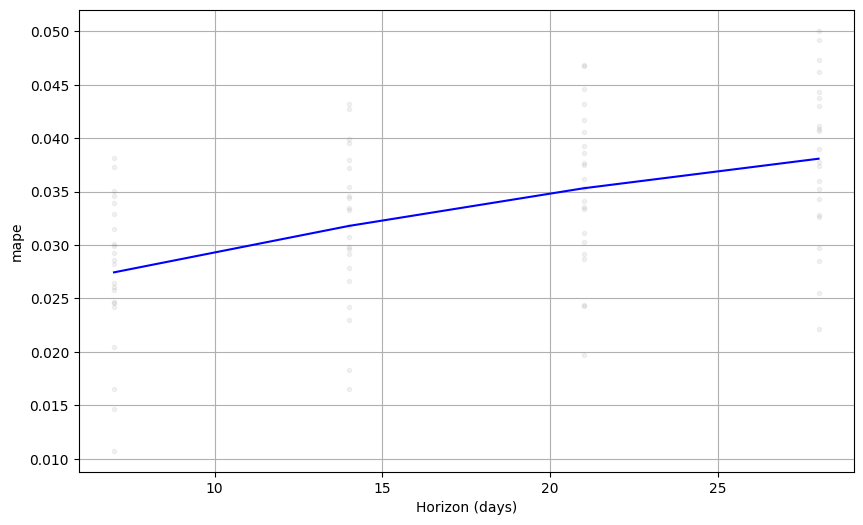

In [39]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='mape')

# Model Parameter Tuning

In [40]:
# Define the parameter grid to search

param_grid = {  'changepoint_prior_scale': [0.05, 0.5],
                'seasonality_prior_scale': [10, 20],
                'holidays_prior_scale': [10, 20],
                'seasonality_mode': ['additive', 'multiplicative']
             }

In [41]:
# Generate all combinations of parameters

from sklearn.model_selection import ParameterGrid

all_params = list(ParameterGrid(param_grid))
len(all_params)
all_params

[{'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 20},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'multiplicative',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'multiplicative',
  'seasonality_prior_scale': 20},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 20,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 20,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 20},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 20,
  'seasonality_mode': 'multiplicative',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prio

In [42]:
# Create a empty list for storing the tuning results

tuning_results = []

for params in all_params:

  # Build the model

  model_prophet = Prophet(
                          yearly_seasonality=True,
                          weekly_seasonality=True,
                          **params
                          )

  model_prophet.add_regressor('temp')
  model_prophet.add_regressor('holiday')
  model_prophet.add_regressor('temp_lag_1')
  model_prophet.add_regressor('temp_lag_2')
  model_prophet.add_regressor('temp_lag_3')

  model_prophet.fit(df)

  # Cross Validation

  df_cv = cross_validation(model_prophet,
                         period='1W',
                         initial='336W',  # = 362-26 weeks
                         horizon='4W',
                         parallel='processes')

  # Compute and store the error

  rmse = performance_metrics(df_cv)['rmse'].mean()
  tuning_results.append(rmse)



INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpmro45p6f/0jwfe31h.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpmro45p6f/ltdwrcpt.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=82337', 'data', 'file=/tmp/tmpmro45p6f/0jwfe31h.json', 'init=/tmp/tmpmro45p6f/ltdwrcpt.json', 'output', 'file=/tmp/tmpmro45p6f/prophet_modelznzd9zww/prophet_model-20250731120723.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:07:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:07:23 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Making 22 forecasts with cutoffs between 2020-07-05 00:00:00 and 2020-11-29 00:00:00
INFO:prophet:Applying in parallel with <conc

In [43]:
tuning_results_df = pd.DataFrame(all_params)
tuning_results_df['rmse'] = tuning_results
tuning_results_df.sort_values(by='rmse', ascending=True)

,changepoint_prior_scale,holidays_prior_scale,seasonality_mode,seasonality_prior_scale,rmse
15,0.50,20,multiplicative,20,12745.257990
10,0.50,10,multiplicative,10,12756.110029
14,0.50,20,multiplicative,10,12766.392082
11,0.50,10,multiplicative,20,12777.137393
2,0.05,10,multiplicative,10,12886.152284
6,0.05,20,multiplicative,10,12889.434352
7,0.05,20,multiplicative,20,12902.904737
3,0.05,10,multiplicative,20,12905.243134
9,0.50,10,additive,20,13241.180414
13,0.50,20,additive,20,13245.131241


In [44]:
# Fetch the best model paramters

best_params = tuning_results_df.loc[tuning_results_df['rmse'].idxmin()]
best_params

,15
changepoint_prior_scale,0.5
holidays_prior_scale,20
seasonality_mode,multiplicative
seasonality_prior_scale,20
rmse,12745.25799


# Predict the Future Using the Trained Model

In [52]:
# Load in original dataset
df = pd.read_csv('/gdrive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Modern Time Series Forecasting Techniques /CAPSTONE PROJECT_ Prophet/DHS_weekly.csv')
df.head()


,Date,Total Individuals in Shelter,Easter,Thanksgiving,Christmas,Temperature
0,1/5/2014,354354,0,0,0,0.848000
1,1/12/2014,358103,0,0,0,3.257143
2,1/19/2014,359491,0,0,0,5.632857
3,1/26/2014,362880,0,0,0,-1.850000
4,2/2/2014,364125,0,0,0,1.177143


In [53]:
df['y'] = df['Total Individuals in Shelter']
df['ds'] = df['Date']
df['ds'] = pd.to_datetime(df['ds'],format='%m/%d/%Y')
df['temp'] = df['Temperature']
df.drop(['Total Individuals in Shelter','Date','Temperature'], axis=1, inplace=True)
df['holiday'] = df['Christmas'] | df['Thanksgiving'] |  df['Easter']
df = df.drop(['Christmas', 'Thanksgiving', 'Easter'], axis=1)
for lag in [1,2,3]:
  df[f'temp_lag_{lag}'] = df['temp'].shift(lag)
df.head()

,y,ds,temp,holiday,temp_lag_1,temp_lag_2,temp_lag_3
0,354354,2014-01-05,0.848000,0,NaN,NaN,NaN
1,358103,2014-01-12,3.257143,0,0.848000,NaN,NaN
2,359491,2014-01-19,5.632857,0,3.257143,0.848000,NaN
3,362880,2014-01-26,-1.850000,0,5.632857,3.257143,0.848000
4,364125,2014-02-02,1.177143,0,-1.850000,5.632857,3.257143


Submit the training data to the tuned Prophet model.

In [54]:
df_train = df.iloc[:-4]
df_train.dropna(inplace=True)

In [56]:
# Remove the 'rmse' key from best_params as Prophet does not accept it as a parameter
best_params_prophet = best_params.drop('rmse').to_dict()

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    **best_params_prophet
    )

model_prophet.add_regressor('temp')
model_prophet.add_regressor('holiday')
model_prophet.add_regressor('temp_lag_1')
model_prophet.add_regressor('temp_lag_2')
model_prophet.add_regressor('temp_lag_3')

model_prophet.fit(df_train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpmro45p6f/hq8odnwp.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpmro45p6f/wh4x8_qm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=53526', 'data', 'file=/tmp/tmpmro45p6f/hq8odnwp.json', 'init=/tmp/tmpmro45p6f/wh4x8_qm.json', 'output', 'file=/tmp/tmpmro45p6f/prophet_modela5ji2q_1/prophet_model-20250731122628.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:26:28 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:26:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


# Generate Forecast

In [57]:
future_regressors = df.drop(columns = ['y','ds'])
future_regressors = future_regressors.dropna()
future_regressors.reset_index(drop=True, inplace=True)
future_regressors

,temp,holiday,temp_lag_1,temp_lag_2,temp_lag_3
0,-1.850000,0,5.632857,3.257143,0.848000
1,1.177143,0,-1.850000,5.632857,3.257143
2,-0.207143,0,1.177143,-1.850000,5.632857
3,-0.738571,0,-0.207143,1.177143,-1.850000
4,4.575714,0,-0.738571,-0.207143,1.177143
...,...,...,...,...,...
358,10.072857,0,12.780000,11.210000,16.122857
359,8.208571,0,10.072857,12.780000,11.210000
360,3.535714,0,8.208571,10.072857,12.780000
361,7.510000,1,3.535714,8.208571,10.072857


In [58]:
# Create a future dataframe

future = model_prophet.make_future_dataframe(periods=4, freq='W')
future = pd.concat([future, future_regressors], axis=1)
future.tail()

,ds,temp,holiday,temp_lag_1,temp_lag_2,temp_lag_3
358,2020-12-06,10.072857,0,12.780000,11.210000,16.122857
359,2020-12-13,8.208571,0,10.072857,12.780000,11.210000
360,2020-12-20,3.535714,0,8.208571,10.072857,12.780000
361,2020-12-27,7.510000,1,3.535714,8.208571,10.072857
362,2021-01-03,6.625000,0,7.510000,3.535714,8.208571


In [59]:
# Generate a forecast

forecast = model_prophet.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,extra_regressors_multiplicative,extra_regressors_multiplicative_lower,extra_regressors_multiplicative_upper,holiday,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
358,2020-12-06,130073.196815,380211.897150,385226.603285,130073.196815,130073.196815,0.005882,0.005882,0.005882,0.000000,...,1.90943,1.90943,1.90943,0.025709,0.025709,0.025709,0.0,0.0,0.0,382547.909363
359,2020-12-13,129849.426728,380601.989992,385494.930378,129849.426728,129849.426728,0.010119,0.010119,0.010119,0.000000,...,1.90943,1.90943,1.90943,0.029253,0.029253,0.029253,0.0,0.0,0.0,382900.378617
360,2020-12-20,129625.656640,380381.560203,385208.390257,129625.656640,129625.656640,0.015621,0.015621,0.015621,0.000000,...,1.90943,1.90943,1.90943,0.028092,0.028092,0.028092,0.0,0.0,0.0,382803.122225
361,2020-12-27,129401.886552,378541.098674,383731.015249,129373.417697,129401.886552,0.011019,0.011019,0.011019,-0.002861,...,1.90943,1.90943,1.90943,0.024089,0.024089,0.024089,0.0,0.0,0.0,381028.749201
362,2021-01-03,129178.116464,377478.232902,382983.246544,129049.358029,129191.386934,0.012005,0.012005,0.012005,0.000000,...,1.90943,1.90943,1.90943,0.023024,0.023024,0.023024,0.0,0.0,0.0,380359.714385


# Visualization of Generated Results

In [60]:
import plotly.express as px
fig = px.line(forecast, x='ds', y='yhat', title='Forecast with Prophet')
fig.show()

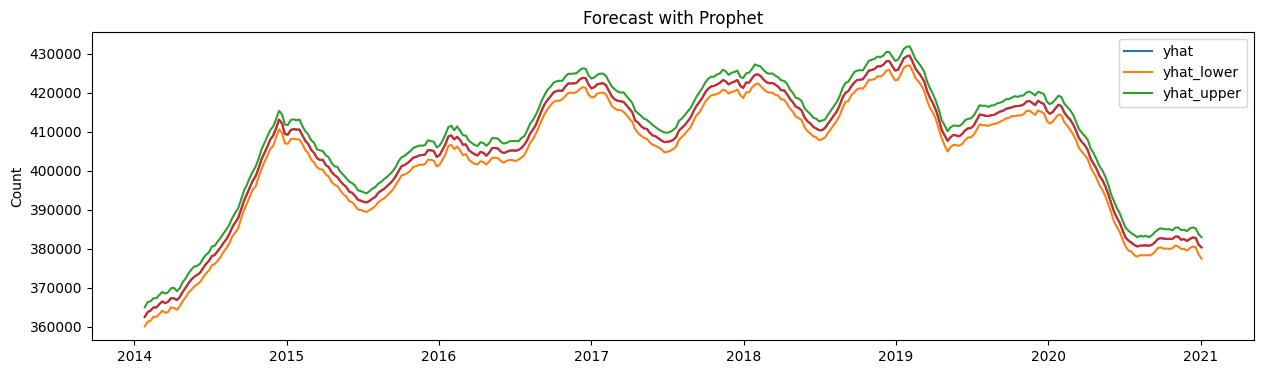

In [61]:
plt.figure(figsize = (15,4))
plt.plot(forecast['ds'], forecast['yhat'],label='yhat')
plt.plot(forecast['ds'], forecast['yhat_lower'],label='yhat_lower')
plt.plot(forecast['ds'], forecast['yhat_upper'],label='yhat_upper')
subset = forecast[forecast['ds'] > '2012-12-01']
plt.title("Forecast with Prophet")
plt.ylabel("Count")
plt.plot(subset['ds'], subset['yhat'])
plt.legend()
plt.show()


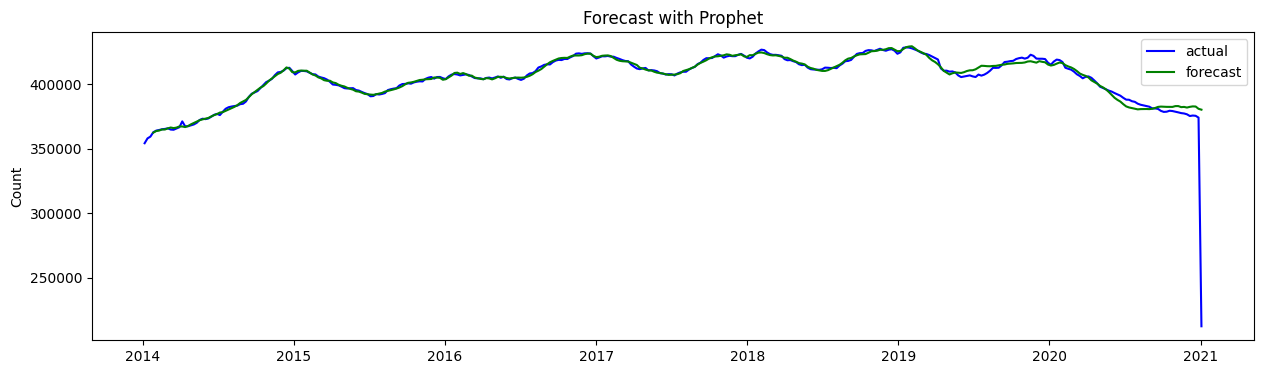

In [62]:
# Visualize time series plot

plt.figure(figsize = (15,4))
plt.plot(df['ds'], df['y'],label='actual',color='blue')
plt.plot(forecast['ds'], forecast['yhat'],label='forecast',color='green')
plt.title("Forecast with Prophet")
plt.ylabel("Count")
plt.legend()
plt.show()

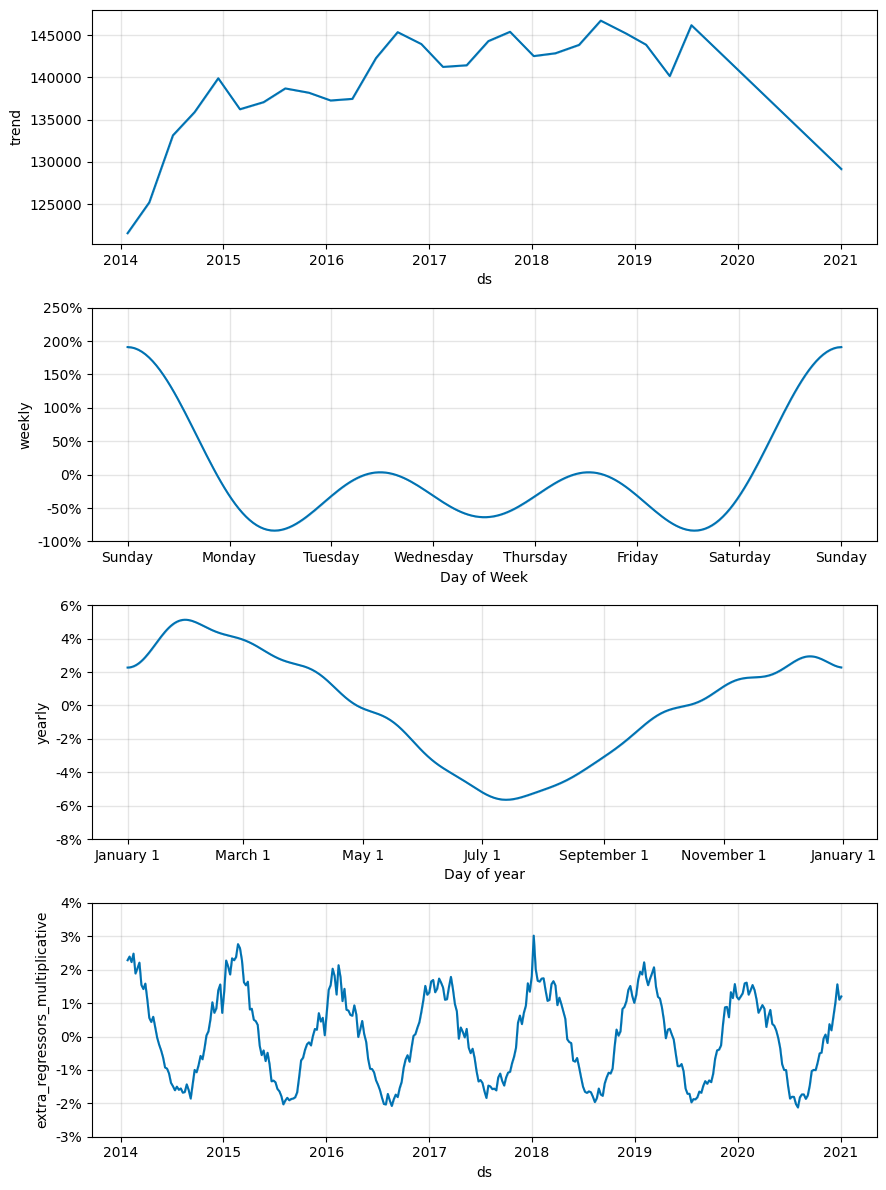

In [63]:
# Visualize components plot

model_prophet.plot_components(forecast)
plt.show()

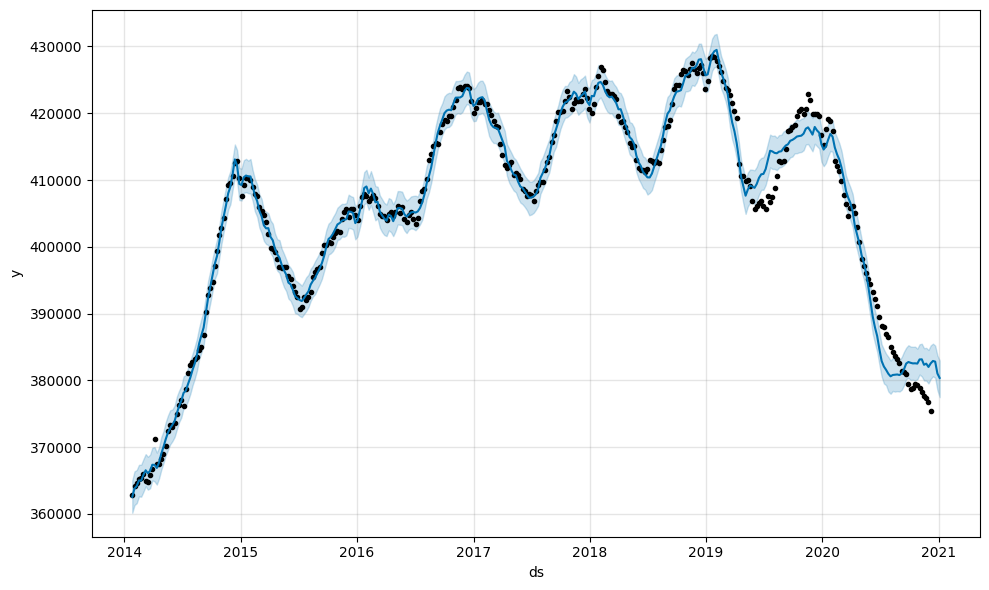

In [64]:
# Visualize forecast plot with uncertainty bounds

model_prophet.plot(forecast)
plt.show()

Plot residuals

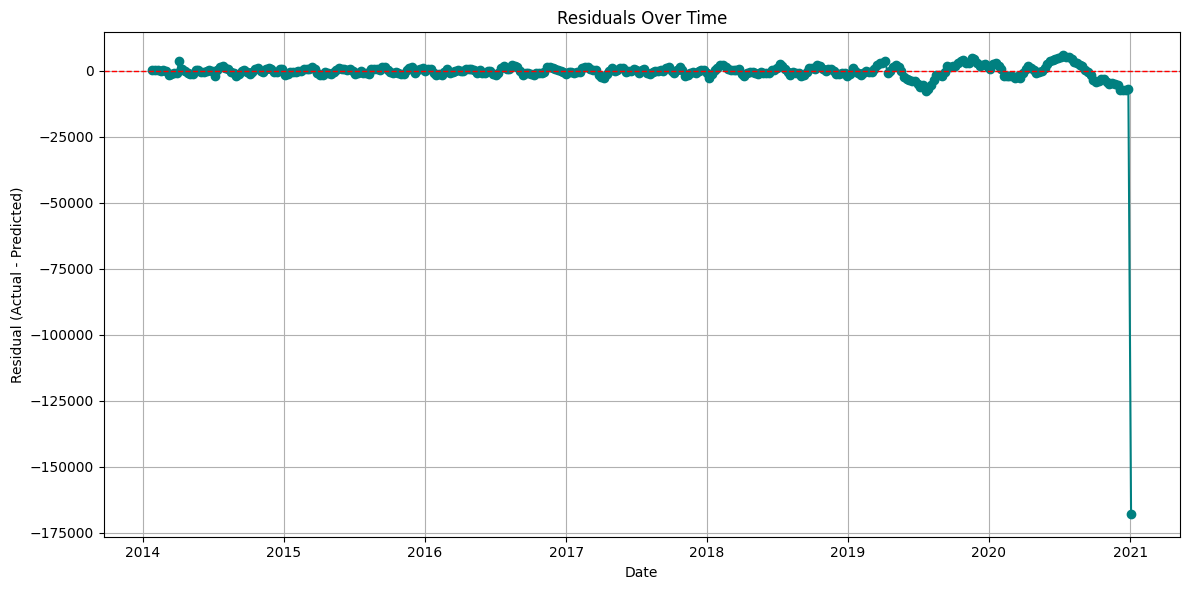

In [65]:
import matplotlib.pyplot as plt

# Merge actuals with forecast
df_merged = df[['ds', 'y']].merge(forecast[['ds', 'yhat']], on='ds')

# Calculate residuals
df_merged['residual'] = df_merged['y'] - df_merged['yhat']

# Plot residuals over time
plt.figure(figsize=(12, 6))
plt.plot(df_merged['ds'], df_merged['residual'], marker='o', linestyle='-', color='teal')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True)
plt.tight_layout()
plt.show()